# EDMD：Koopman 算子的数据驱动近似（对应书中 §4.5）

$$K = G^{+}A,\qquad
G=\frac1M\sum_m \Psi(x_m)\Psi(x_m)^\top,\quad
A=\frac1M\sum_m \Psi(x_m)\Psi(y_m)^\top$$

测试系统（存在精确的 3 维 Koopman 不变子空间 $\Psi=(x_1,\,x_2,\,x_1^2)$）：

$$\dot x_1=\mu x_1,\qquad \dot x_2=\lambda\,(x_2-x_1^2),\qquad (\mu,\lambda)=(-0.05,\,-1)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
mu, lam, dt = -0.05, -1.0, 0.02

def flow(s, dt):
    """精确解推进一步（该系统有闭式解）。"""
    x1, x2 = s[..., 0], s[..., 1]
    c = x2 - x1 ** 2 * lam / (lam - 2 * mu)
    x1n = x1 * np.exp(mu * dt)
    x2n = c * np.exp(lam * dt) + lam / (lam - 2 * mu) * x1n ** 2
    return np.stack([x1n, x2n], axis=-1)

# 采集快照对 (x_m, y_m = F(x_m))
M = 2000
Xs = np.random.uniform(-2, 2, size=(M, 2))
Ys = flow(Xs, dt)

In [2]:
def psi(s):
    """字典函数 Psi = (x1, x2, x1^2)。"""
    return np.stack([s[:, 0], s[:, 1], s[:, 0] ** 2], axis=1)

PX, PY = psi(Xs), psi(Ys)
G = PX.T @ PX / M
A = PX.T @ PY / M
K = np.linalg.pinv(G) @ A          # EDMD 得到的 Koopman 矩阵

print("K (EDMD):\n", K.round(4))
print("\nKoopman 特征值 (log/dt):", np.round(np.log(np.linalg.eigvals(K)) / dt, 4))
print("理论值:", [mu, lam, 2 * mu])

K (EDMD):
 [[ 0.999   0.     -0.    ]
 [ 0.      0.9802  0.    ]
 [-0.      0.0198  0.998 ]]

Koopman 特征值 (log/dt): [-0.05 -1.   -0.1 ]
理论值: [-0.05, -1.0, -0.1]


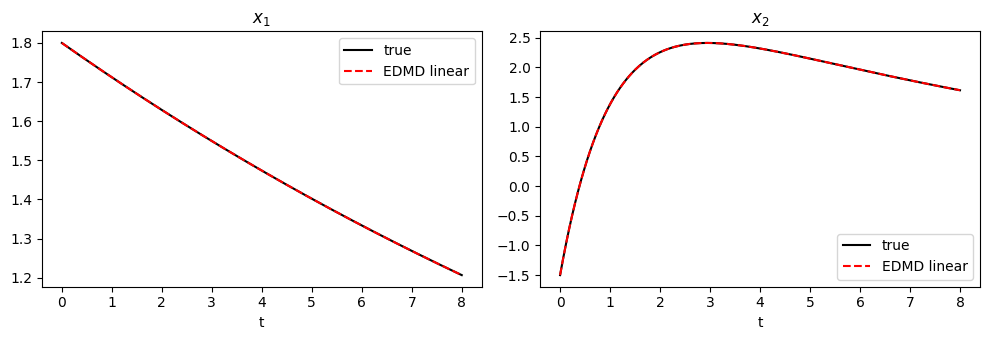

轨迹最大误差: 8.186784583585904e-13


In [3]:
# 在提升空间做纯线性预测，与真实轨迹对比
n_steps = 400
s = np.array([[1.8, -1.5]])
true_traj = [s[0]]
for _ in range(n_steps):
    s = flow(s, dt)
    true_traj.append(s[0])
true_traj = np.array(true_traj)

z = psi(np.array([[1.8, -1.5]]))[0]
lin_traj = [z[:2]]
for _ in range(n_steps):
    z = z @ K                       # 线性推进
    lin_traj.append(z[:2])
lin_traj = np.array(lin_traj)

t = np.arange(n_steps + 1) * dt
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for i, name in enumerate(["$x_1$", "$x_2$"]):
    axes[i].plot(t, true_traj[:, i], "k-", label="true")
    axes[i].plot(t, lin_traj[:, i], "r--", label="EDMD linear")
    axes[i].set_xlabel("t"); axes[i].set_title(name); axes[i].legend()
plt.tight_layout(); plt.show()

print("轨迹最大误差:", np.abs(true_traj - lin_traj).max())